In [5]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:

graph_from_osm = ox.load_graphml('./data/karlsruhe_graph.graphml')

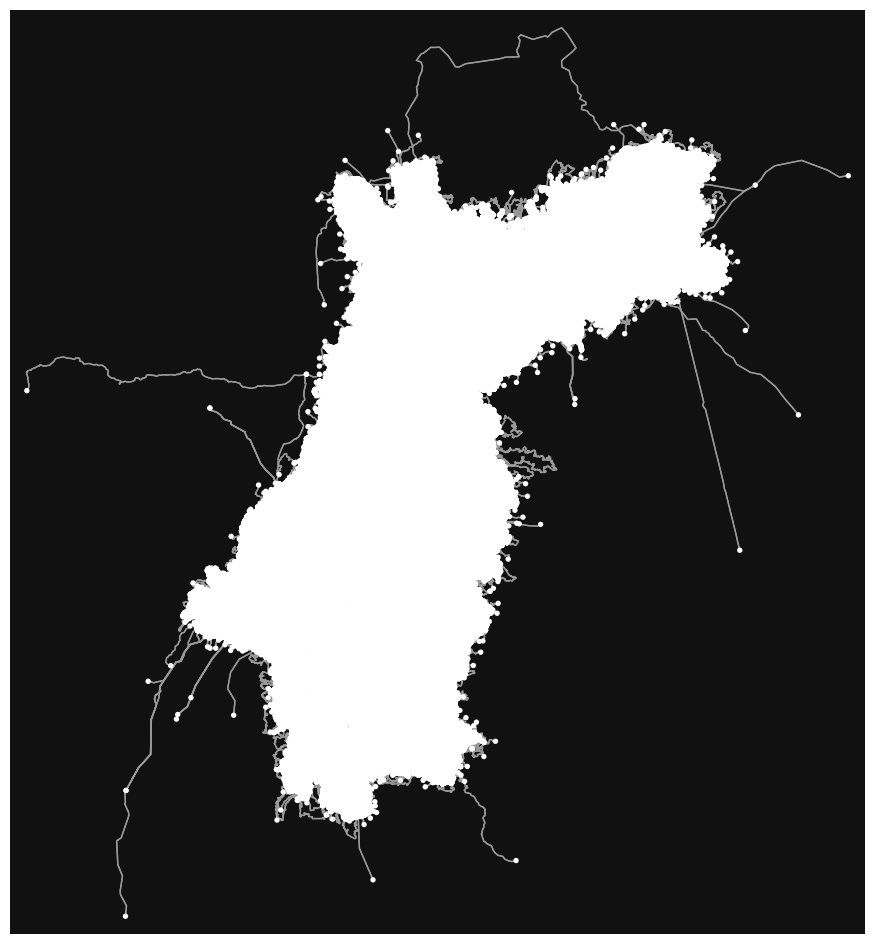

In [4]:
fig, ax = ox.plot_graph(graph_from_osm, figsize=(12, 12))

In [6]:
nodes, edges = ox.convert.graph_to_gdfs(graph_from_osm)
edges.head()

osmid   access  highway oneway reversed  \
u          v          key                                                
3237898488 3237898490 0    317518238  private  service  False    False   
           3237898499 0    317518238  private  service  False     True   
           3237898496 0    317518239  private  service  False    False   
3237898490 2480322405 0    240294833  private  service  False    False   
           8860745034 0    240294833  private  service  False     True   

                              length  \
u          v          key              
3237898488 3237898490 0    13.474710   
           3237898499 0    19.848006   
           3237898496 0    39.690609   
3237898490 2480322405 0    25.948204   
           8860745034 0    24.113799   

                                                                    geometry  \
u          v          key                                                      
3237898488 3237898490 0    LINESTRING (8.46868 49.53287, 8.46872 49.53281...   
           3237898499 0    LINESTRING (8.46868 49.53287, 8.4686 49.53291,...   
           3237898496 0    LINESTRING (8.46868 49.53287, 8.46876 49.53287...   
3237898490 2480322405 0      LINESTRING (8.46871 49.53275, 8.46901 49.53288)   
           8860745034 0      LINESTRING (8.46871 49.53275, 8.46844 49.53263)   

                          landuse name maxspeed width  ref tunnel service  \
u          v          key                                                   
3237898488 3237898490 0       NaN  NaN      NaN   NaN  NaN    NaN     NaN   
           3237898499 0       NaN  NaN      NaN   NaN  NaN    NaN     NaN   
           3237898496 0       NaN  NaN      NaN   NaN  NaN    NaN     NaN   
3237898490 2480322405 0       NaN  NaN      NaN   NaN  NaN    NaN     NaN   
           8860745034 0       NaN  NaN      NaN   NaN  NaN    NaN     NaN   

                          lanes bridge area junction est_width  
u          v          key                                       
3237898488 3237898490 0     NaN    NaN  NaN      NaN       NaN  
           3237898499 0     NaN    NaN  NaN      NaN       NaN  
           3237898496 0     NaN    NaN  NaN      NaN       NaN  
3237898490 2480322405 0     NaN    NaN  NaN      NaN       NaN  
           8860745034 0     NaN    NaN  NaN      NaN       NaN

### Visualize streets only

In [7]:
# Define street types to keep (drivable roads)
street_types = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 
                'residential', 'motorway_link', 'trunk_link', 'primary_link',
                'secondary_link', 'tertiary_link']

# Filter edges - handle both string and list highway values
def is_street(highway_value):
    if isinstance(highway_value, list):
        return any(h in street_types for h in highway_value)
    return highway_value in street_types

streets_only = edges[edges['highway'].apply(is_street)]
print(f"Total edges: {len(edges)}")
print(f"Street edges only: {len(streets_only)}")
streets_only.head()

Total edges: 7988662
Street edges only: 479266


osmid access      highway oneway reversed  \
u          v          key                                                  
3372220897 476876939  0    330266102    NaN  residential  False    False   
           3372220899 0    330266102    NaN  residential  False     True   
           3372220901 0    330266124    NaN  residential  False     True   
3372220899 3372220897 0    330266102    NaN  residential  False    False   
           3372220903 0    330266102    NaN  residential  False     True   

                              length  \
u          v          key              
3372220897 476876939  0     7.483792   
           3372220899 0    22.934595   
           3372220901 0    40.525251   
3372220899 3372220897 0    22.934595   
           3372220903 0    19.131632   

                                                                    geometry  \
u          v          key                                                      
3372220897 476876939  0      LINESTRING (8.46799 48.49784, 8.46799 48.49777)   
           3372220899 0      LINESTRING (8.46799 48.49784, 8.46787 48.49803)   
           3372220901 0    LINESTRING (8.46799 48.49784, 8.4682 48.49788,...   
3372220899 3372220897 0      LINESTRING (8.46787 48.49803, 8.46799 48.49784)   
           3372220903 0      LINESTRING (8.46787 48.49803, 8.46777 48.49819)   

                          landuse     name maxspeed width  ref tunnel service  \
u          v          key                                                       
3372220897 476876939  0       NaN  Ratsweg      NaN   NaN  NaN    NaN     NaN   
           3372220899 0       NaN  Ratsweg      NaN   NaN  NaN    NaN     NaN   
           3372220901 0       NaN  Ratsweg      NaN   NaN  NaN    NaN     NaN   
3372220899 3372220897 0       NaN  Ratsweg      NaN   NaN  NaN    NaN     NaN   
           3372220903 0       NaN  Ratsweg      NaN   NaN  NaN    NaN     NaN   

                          lanes bridge area junction est_width  
u          v          key                                       
3372220897 476876939  0     NaN    NaN  NaN      NaN       NaN  
           3372220899 0     NaN    NaN  NaN      NaN       NaN  
           3372220901 0     NaN    NaN  NaN      NaN       NaN  
3372220899 3372220897 0     NaN    NaN  NaN      NaN       NaN  
           3372220903 0     NaN    NaN  NaN      NaN       NaN

### Filter for main streets only (exclude footpaths, cycleways, etc.)

In [8]:
# Check unique highway types in the graph
edges['highway'].value_counts()

highway
track                                      568644
service                                    328046
residential                                316185
footway                                    245695
path                                       164679
                                            ...  
[pedestrian, footway, service]                  1
[footway, pedestrian, service]                  1
[living_street, unclassified, tertiary]         1
[track, unclassified, tertiary]                 1
[track, path, cycleway]                         1
Name: count, Length: 253, dtype: int64

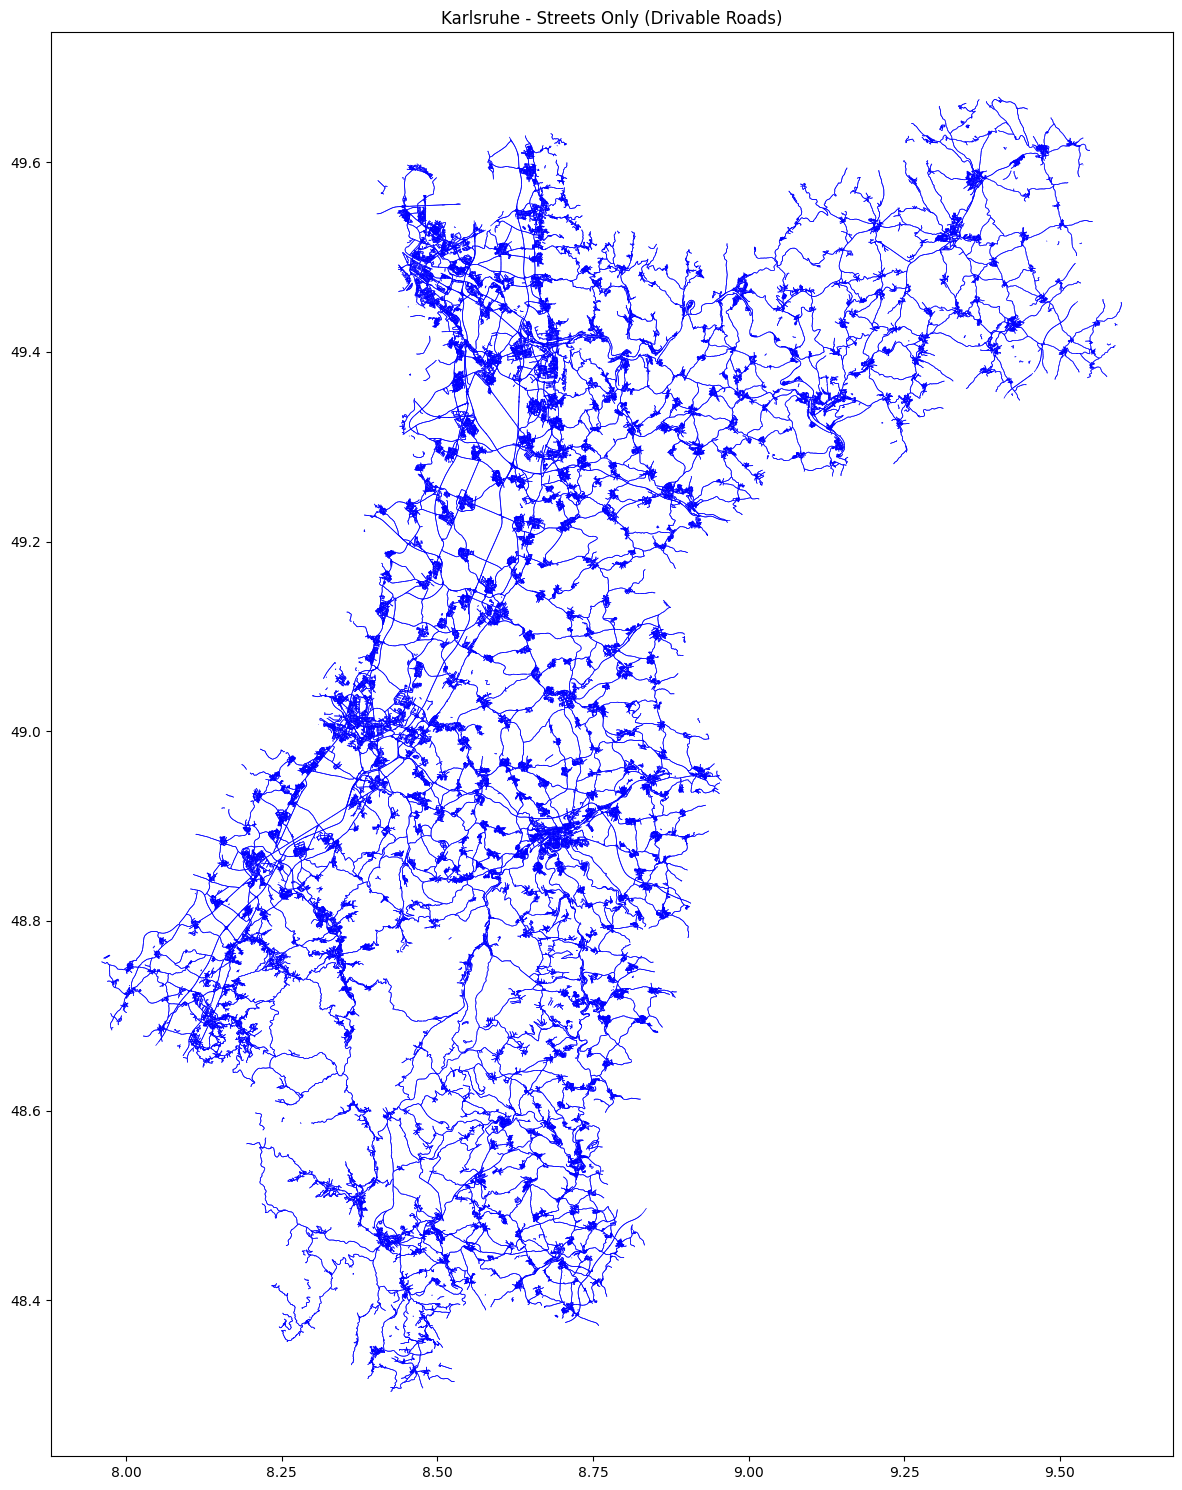

In [9]:
fig, ax = plt.subplots(figsize=(15, 15))
streets_only.plot(ax=ax, linewidth=0.5, color='blue')
ax.set_title('Karlsruhe - Streets Only (Drivable Roads)')
plt.tight_layout()
plt.show()

## Lightweight Export for Vehicle Localization

For map-matching (projecting vehicle position onto nearest street), you need:
1. **Edge geometries** - LineString coordinates of each street segment
2. **Node coordinates** - Start/end points for spatial operations
3. **Optional metadata** - Road type, one-way info, speed limits

In [10]:
print("Available edge columns:")
print(edges.columns.tolist())

Available edge columns:
['osmid', 'access', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'landuse', 'name', 'maxspeed', 'width', 'ref', 'tunnel', 'service', 'lanes', 'bridge', 'area', 'junction', 'est_width']


In [11]:
essential_edge_columns = [
    'geometry',      # LineString - the road shape (MOST IMPORTANT)
    'highway',       # Road type (for filtering)
    'oneway',        # Direction constraint
    'length',        # Segment length
    'maxspeed',      # Optional - for validation
    'name',          # Optional - for debugging
]

available_essential = [col for col in essential_edge_columns if col in edges.columns]
print(f"Keeping columns: {available_essential}")

edges_lightweight = edges[available_essential].copy()

edges_lightweight = edges_lightweight[edges_lightweight['highway'].apply(is_street)]

print(f"\nLightweight edges shape: {edges_lightweight.shape}")
print(f"Memory usage: {edges_lightweight.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
edges_lightweight.head()

Keeping columns: ['geometry', 'highway', 'oneway', 'length', 'maxspeed', 'name']

Lightweight edges shape: (479266, 6)
Memory usage: 140.09 MB


geometry  \
u          v          key                                                      
3372220897 476876939  0      LINESTRING (8.46799 48.49784, 8.46799 48.49777)   
           3372220899 0      LINESTRING (8.46799 48.49784, 8.46787 48.49803)   
           3372220901 0    LINESTRING (8.46799 48.49784, 8.4682 48.49788,...   
3372220899 3372220897 0      LINESTRING (8.46787 48.49803, 8.46799 48.49784)   
           3372220903 0      LINESTRING (8.46787 48.49803, 8.46777 48.49819)   

                               highway oneway     length maxspeed     name  
u          v          key                                                   
3372220897 476876939  0    residential  False   7.483792      NaN  Ratsweg  
           3372220899 0    residential  False  22.934595      NaN  Ratsweg  
           3372220901 0    residential  False  40.525251      NaN  Ratsweg  
3372220899 3372220897 0    residential  False  22.934595      NaN  Ratsweg  
           3372220903 0    residential  False  19.131632      NaN  Ratsweg

In [12]:
# Extract node coordinates (needed for spatial operations)
print("Available node columns:")
print(nodes.columns.tolist())

# Keep only essential node data
nodes_lightweight = nodes[['y', 'x', 'geometry']].copy()  # y=lat, x=lon
print(f"\nLightweight nodes shape: {nodes_lightweight.shape}")
print(f"Memory usage: {nodes_lightweight.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
nodes_lightweight.head()

Available node columns:
['y', 'x', 'highway', 'railway', 'ref', 'junction', 'geometry']

Lightweight nodes shape: (1947492, 3)
Memory usage: 59.43 MB


,y,x,geometry
osmid,,,
3237898488,49.532868,8.468679,POINT (8.46868 49.53287)
3237898490,49.532751,8.468713,POINT (8.46871 49.53275)
3791650886,49.077481,8.694214,POINT (8.69421 49.07748)
3791650887,49.078562,8.691495,POINT (8.69149 49.07856)
3791650888,49.078598,8.691446,POINT (8.69145 49.0786)


In [13]:
edges_lightweight

geometry  \
u           v           key                                                      
3372220897  476876939   0      LINESTRING (8.46799 48.49784, 8.46799 48.49777)   
            3372220899  0      LINESTRING (8.46799 48.49784, 8.46787 48.49803)   
            3372220901  0    LINESTRING (8.46799 48.49784, 8.4682 48.49788,...   
3372220899  3372220897  0      LINESTRING (8.46787 48.49803, 8.46799 48.49784)   
            3372220903  0      LINESTRING (8.46787 48.49803, 8.46777 48.49819)   
...                                                                        ...   
11425283862 62902954    0      LINESTRING (8.19677 48.80719, 8.19677 48.80723)   
1258290981  727718138   0      LINESTRING (8.29508 48.47446, 8.29544 48.47426)   
            10676256128 0       LINESTRING (8.29508 48.47446, 8.29451 48.4748)   
1313833124  446191608   0    LINESTRING (8.15818 48.6561, 8.15829 48.65617,...   
3707764725  859482613   0    LINESTRING (8.61095 49.46993, 8.61108 49.46998...   

                                 highway oneway     length maxspeed  \
u           v           key                                           
3372220897  476876939   0    residential  False   7.483792      NaN   
            3372220899  0    residential  False  22.934595      NaN   
            3372220901  0    residential  False  40.525251      NaN   
3372220899  3372220897  0    residential  False  22.934595      NaN   
            3372220903  0    residential  False  19.131632      NaN   
...                                  ...    ...        ...      ...   
11425283862 62902954    0       tertiary  False   4.261818       50   
1258290981  727718138   0        primary  False  34.609919       50   
            10676256128 0        primary  False  56.144427       50   
1313833124  446191608   0    residential  False  78.118728      NaN   
3707764725  859482613   0    residential  False  53.857720       30   

                                           name  
u           v           key                      
3372220897  476876939   0               Ratsweg  
            3372220899  0               Ratsweg  
            3372220901  0               Ratsweg  
3372220899  3372220897  0               Ratsweg  
            3372220903  0               Ratsweg  
...                                         ...  
11425283862 62902954    0    Sandweierer Straße  
1258290981  727718138   0    Straßburger Straße  
            10676256128 0    Straßburger Straße  
1313833124  446191608   0             Tannenweg  
3707764725  859482613   0       Realschulstraße  

[479266 rows x 6 columns]

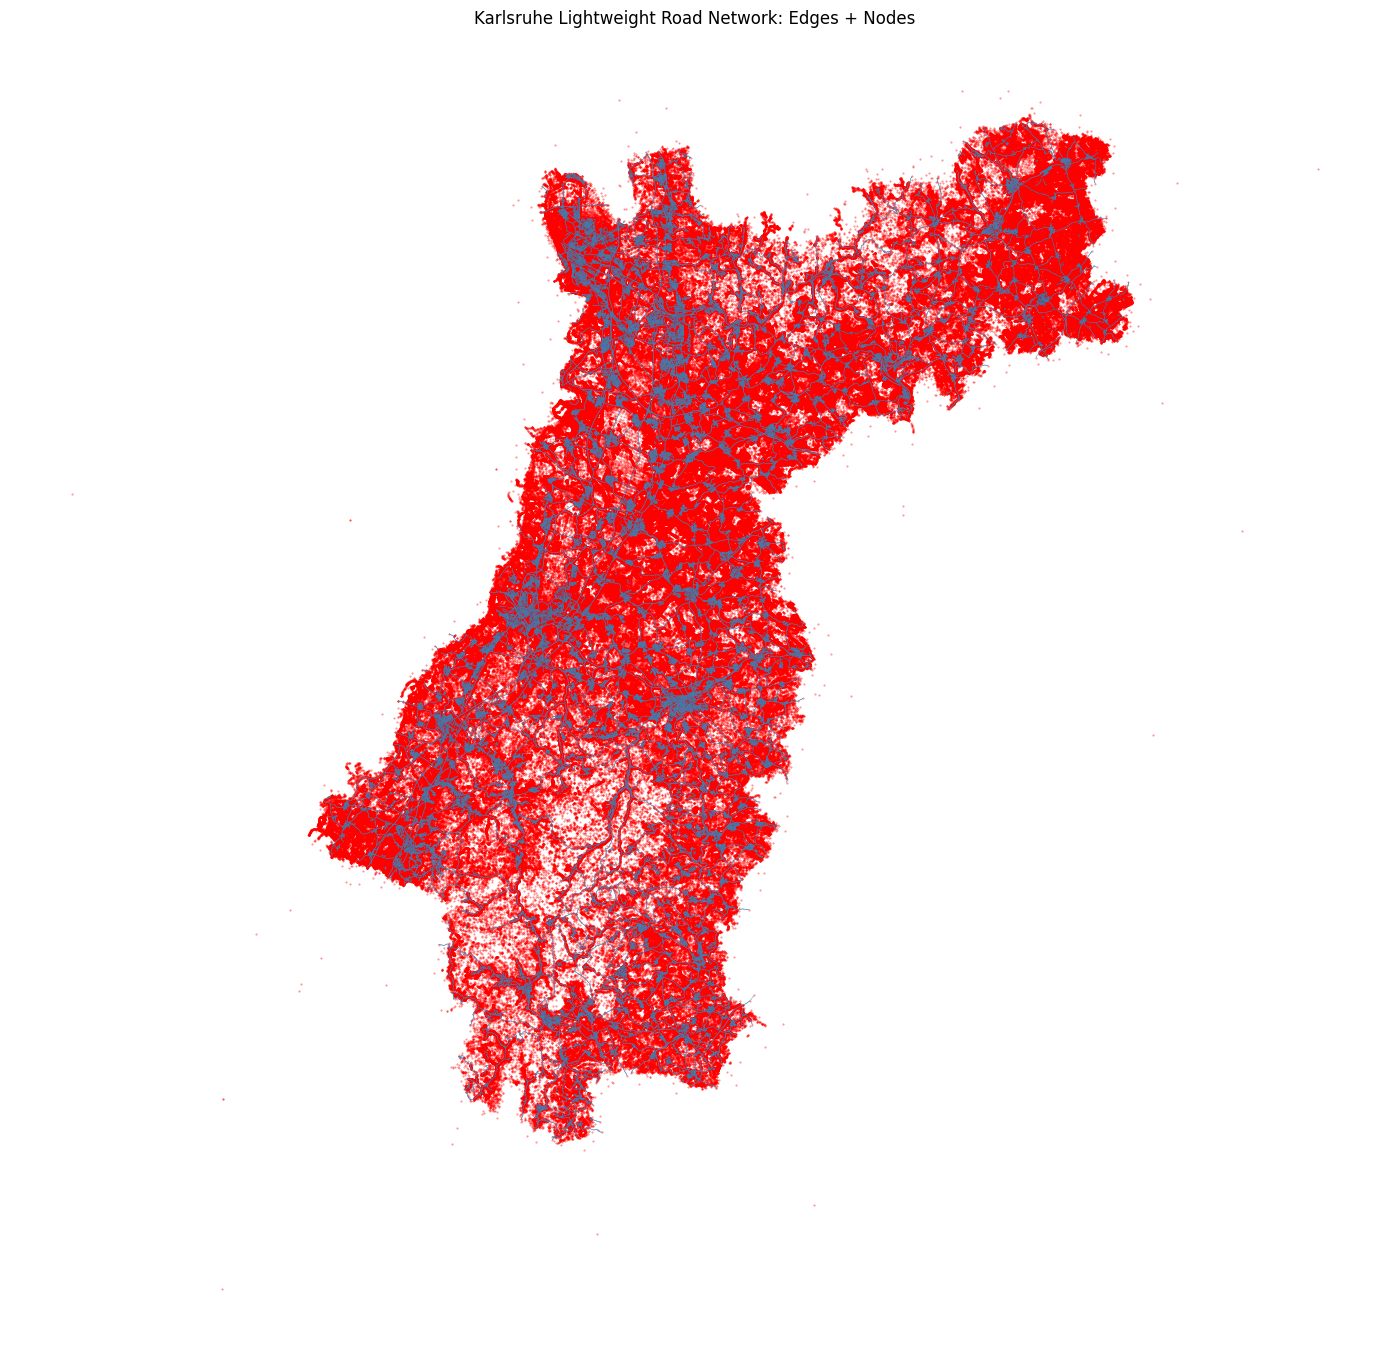

In [14]:
# Use whichever variable name exists: edges_lightweights (if created) or edges_lightweight
edges_to_plot = edges_lightweight

fig, ax = plt.subplots(figsize=(14, 14))

# Plot edges first
edges_to_plot.plot(ax=ax, linewidth=0.4, color='steelblue', alpha=0.8)

# Plot nodes on top
nodes_lightweight.plot(ax=ax, markersize=0.2, color='red', alpha=0.5)

ax.set_title("Karlsruhe Lightweight Road Network: Edges + Nodes")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Save as Parquet

In [15]:
def normalize_value(value):
    """Convert lists to their first element, keep other values as-is"""
    if isinstance(value, list):
        return value[0] if value else None  # Take first value from list
    return value

# Apply normalization to all non-geometry columns
for col in edges_lightweight.columns:
    if col != 'geometry':  # Don't touch geometry column
        edges_lightweight[col] = edges_lightweight[col].apply(normalize_value)

print("Normalized columns for Parquet compatibility")
print(f"Columns: {edges_lightweight.columns.tolist()}")
edges_lightweight.head()

Normalized columns for Parquet compatibility
Columns: ['geometry', 'highway', 'oneway', 'length', 'maxspeed', 'name']


geometry  \
u          v          key                                                      
3372220897 476876939  0      LINESTRING (8.46799 48.49784, 8.46799 48.49777)   
           3372220899 0      LINESTRING (8.46799 48.49784, 8.46787 48.49803)   
           3372220901 0    LINESTRING (8.46799 48.49784, 8.4682 48.49788,...   
3372220899 3372220897 0      LINESTRING (8.46787 48.49803, 8.46799 48.49784)   
           3372220903 0      LINESTRING (8.46787 48.49803, 8.46777 48.49819)   

                               highway  oneway     length maxspeed     name  
u          v          key                                                    
3372220897 476876939  0    residential   False   7.483792      NaN  Ratsweg  
           3372220899 0    residential   False  22.934595      NaN  Ratsweg  
           3372220901 0    residential   False  40.525251      NaN  Ratsweg  
3372220899 3372220897 0    residential   False  22.934595      NaN  Ratsweg  
           3372220903 0    residential   False  19.131632      NaN  Ratsweg

In [17]:
# Save as Parquet (fast, compact, preserves geometry)
edges_lightweight.to_parquet('./data/karlsruhe_edges.parquet')
nodes_lightweight.to_parquet('./data/karlsruhe_nodes.parquet')
print("Saved lightweight edge and node data!")

Saved lightweight edge and node data!


### Fast Loading of Lightweight Data

In [18]:
edges_map = gpd.read_parquet('./data/karlsruhe_edges.parquet')
nodes_map = gpd.read_parquet('./data/karlsruhe_nodes.parquet')

print(f"Loaded {len(edges_map)} edges and {len(nodes_map)} nodes")
print(f"Total memory: {(edges_map.memory_usage(deep=True).sum() + nodes_map.memory_usage(deep=True).sum()) / 1024**2:.2f} MB")

Loaded 479266 edges and 1947492 nodes
Total memory: 155.56 MB


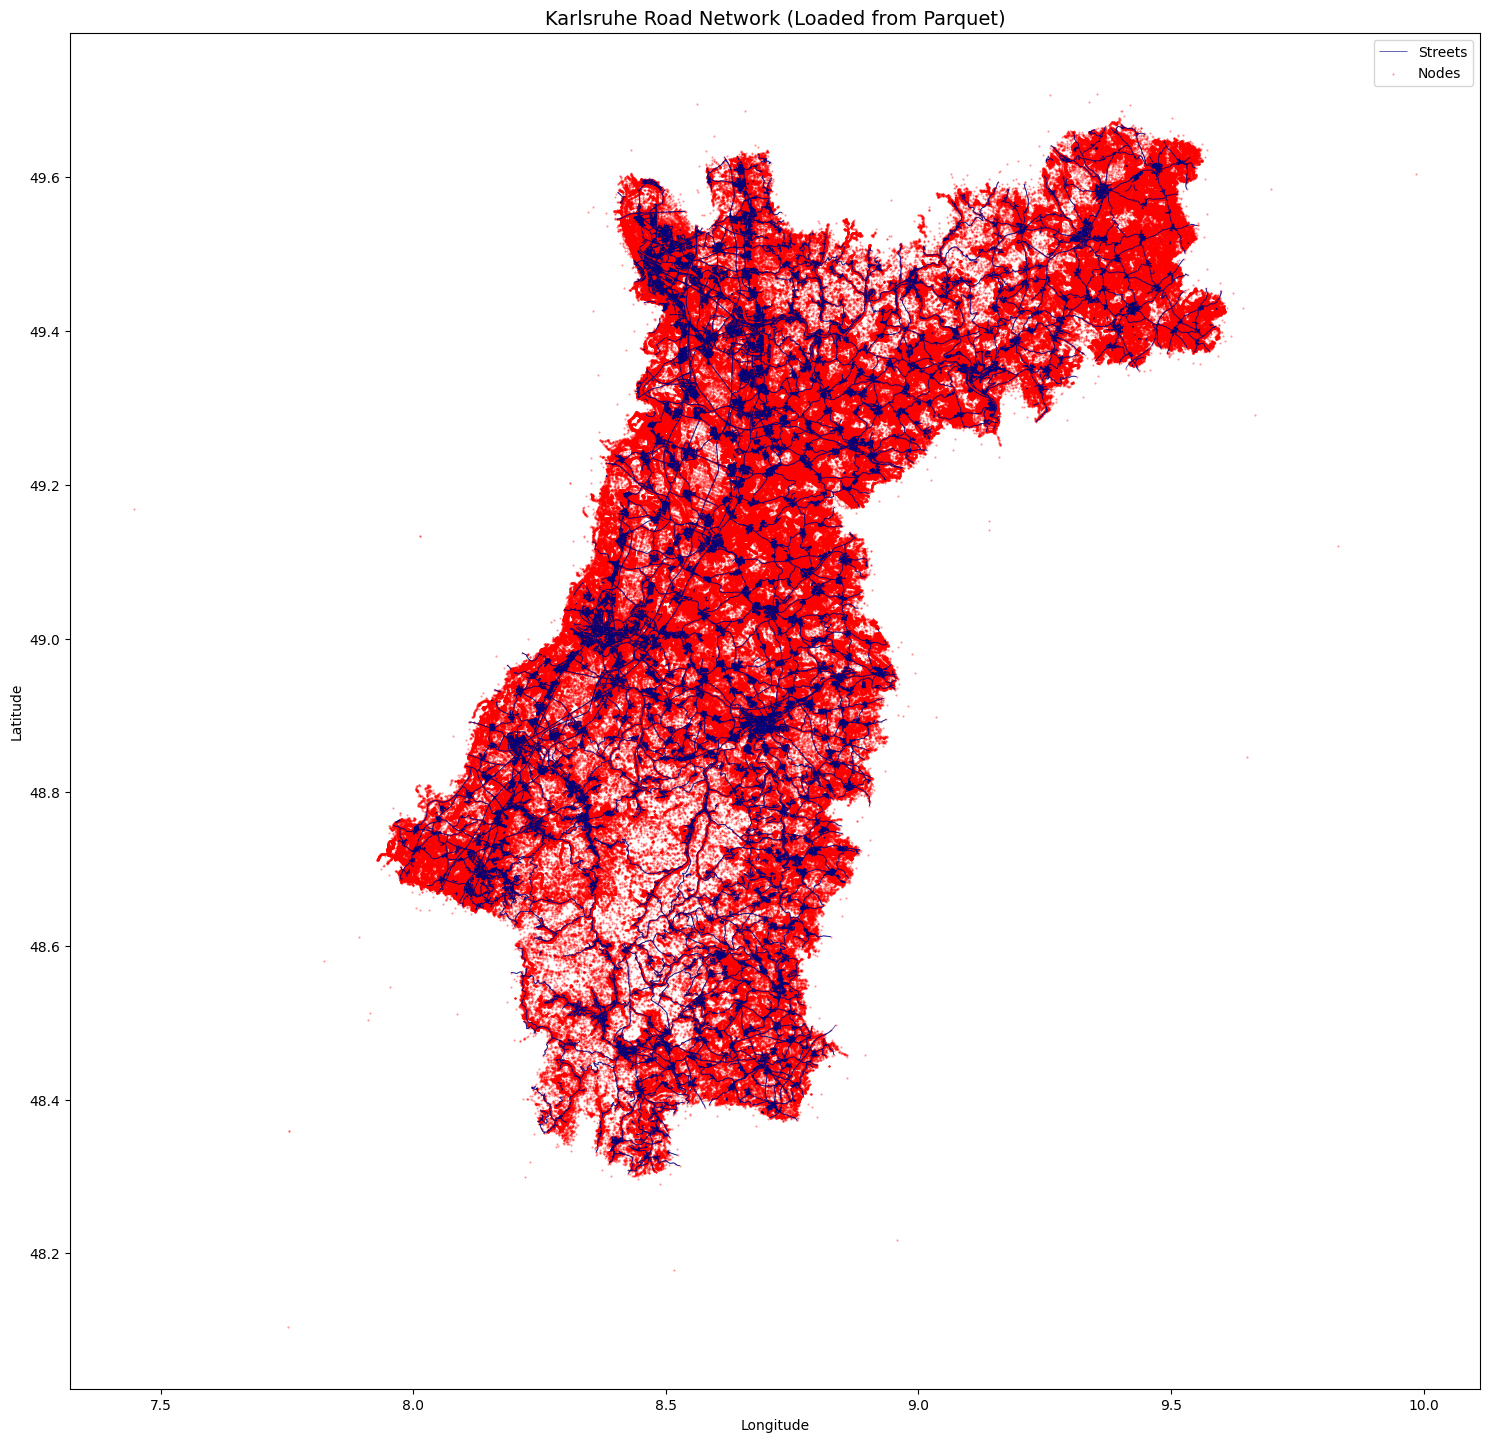

In [19]:
# Visualize the loaded lightweight data
fig, ax = plt.subplots(figsize=(15, 15))

# Plot edges
edges_map.plot(ax=ax, linewidth=0.6, color='navy', alpha=0.7, label='Streets')

# Plot nodes
nodes_map.plot(ax=ax, markersize=0.3, color='red', alpha=0.4, label='Nodes')

ax.set_title('Karlsruhe Road Network (Loaded from Parquet)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
edges_map

geometry  \
u           v           key                                                      
3372220897  476876939   0      LINESTRING (8.46799 48.49784, 8.46799 48.49777)   
            3372220899  0      LINESTRING (8.46799 48.49784, 8.46787 48.49803)   
            3372220901  0    LINESTRING (8.46799 48.49784, 8.4682 48.49788,...   
3372220899  3372220897  0      LINESTRING (8.46787 48.49803, 8.46799 48.49784)   
            3372220903  0      LINESTRING (8.46787 48.49803, 8.46777 48.49819)   
...                                                                        ...   
11425283862 62902954    0      LINESTRING (8.19677 48.80719, 8.19677 48.80723)   
1258290981  727718138   0      LINESTRING (8.29508 48.47446, 8.29544 48.47426)   
            10676256128 0       LINESTRING (8.29508 48.47446, 8.29451 48.4748)   
1313833124  446191608   0    LINESTRING (8.15818 48.6561, 8.15829 48.65617,...   
3707764725  859482613   0    LINESTRING (8.61095 49.46993, 8.61108 49.46998...   

                                 highway  oneway     length maxspeed  \
u           v           key                                            
3372220897  476876939   0    residential   False   7.483792      NaN   
            3372220899  0    residential   False  22.934595      NaN   
            3372220901  0    residential   False  40.525251      NaN   
3372220899  3372220897  0    residential   False  22.934595      NaN   
            3372220903  0    residential   False  19.131632      NaN   
...                                  ...     ...        ...      ...   
11425283862 62902954    0       tertiary   False   4.261818       50   
1258290981  727718138   0        primary   False  34.609919       50   
            10676256128 0        primary   False  56.144427       50   
1313833124  446191608   0    residential   False  78.118728      NaN   
3707764725  859482613   0    residential   False  53.857720       30   

                                           name  
u           v           key                      
3372220897  476876939   0               Ratsweg  
            3372220899  0               Ratsweg  
            3372220901  0               Ratsweg  
3372220899  3372220897  0               Ratsweg  
            3372220903  0               Ratsweg  
...                                         ...  
11425283862 62902954    0    Sandweierer Straße  
1258290981  727718138   0    Straßburger Straße  
            10676256128 0    Straßburger Straße  
1313833124  446191608   0             Tannenweg  
3707764725  859482613   0       Realschulstraße  

[479266 rows x 6 columns]

### Example: Map-Matching Function

In [22]:
# Example: Project vehicle position onto nearest street edge
from shapely.geometry import Point
from shapely.ops import nearest_points

def project_to_nearest_edge(lat, lon, edges_gdf, max_distance=50):
    """
    Project a vehicle position onto the nearest street edge.
    
    Args:
        lat, lon: Vehicle position
        edges_gdf: GeoDataFrame with street edges
        max_distance: Maximum search distance in meters
        
    Returns:
        dict with projected point, nearest edge info, and distance
    """
    vehicle_point = Point(lon, lat)
    
    # Find distances to all edges
    edges_gdf['distance'] = edges_gdf.geometry.distance(vehicle_point)
    
    # Get nearest edge
    nearest_idx = edges_gdf['distance'].idxmin()
    nearest_edge = edges_gdf.loc[nearest_idx]
    
    # Check if within max distance (convert degrees to approximate meters at this latitude)
    distance_m = nearest_edge['distance'] * 111000  # rough conversion
    
    if distance_m > max_distance:
        return None
    
    # Project point onto the edge
    nearest_point_on_edge = nearest_points(vehicle_point, nearest_edge.geometry)[1]
    
    return {
        'projected_point': nearest_point_on_edge,
        'projected_lat': nearest_point_on_edge.y,
        'projected_lon': nearest_point_on_edge.x,
        'distance_m': distance_m,
        'edge_index': nearest_idx,
        'highway_type': nearest_edge['highway'],
        'edge_length': nearest_edge['length']
    }

# Test the function
test_lat, test_lon = 48.972103212661, 8.4761506974488
result = project_to_nearest_edge(test_lat, test_lon, edges_map)
print(result)

{'projected_point': <POINT (8.476 48.972)>, 'projected_lat': 48.9720853, 'projected_lon': 8.4762483, 'distance_m': np.float64(11.014825603404962), 'edge_index': (np.int64(10606061527), np.int64(356812004), np.int64(0)), 'highway_type': 'footway', 'edge_length': np.float64(147.72196566317675)}


/var/folders/wp/k21z2hls3psg217yqzgszlx80000gn/T/ipykernel_39661/745390146.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges_gdf['distance'] = edges_gdf.geometry.distance(vehicle_point)
